# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np

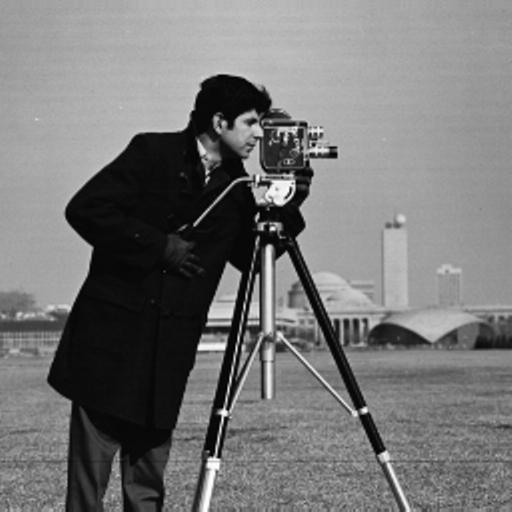

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraMan.png")
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
# scaling factors
cx = 2
cy = 2

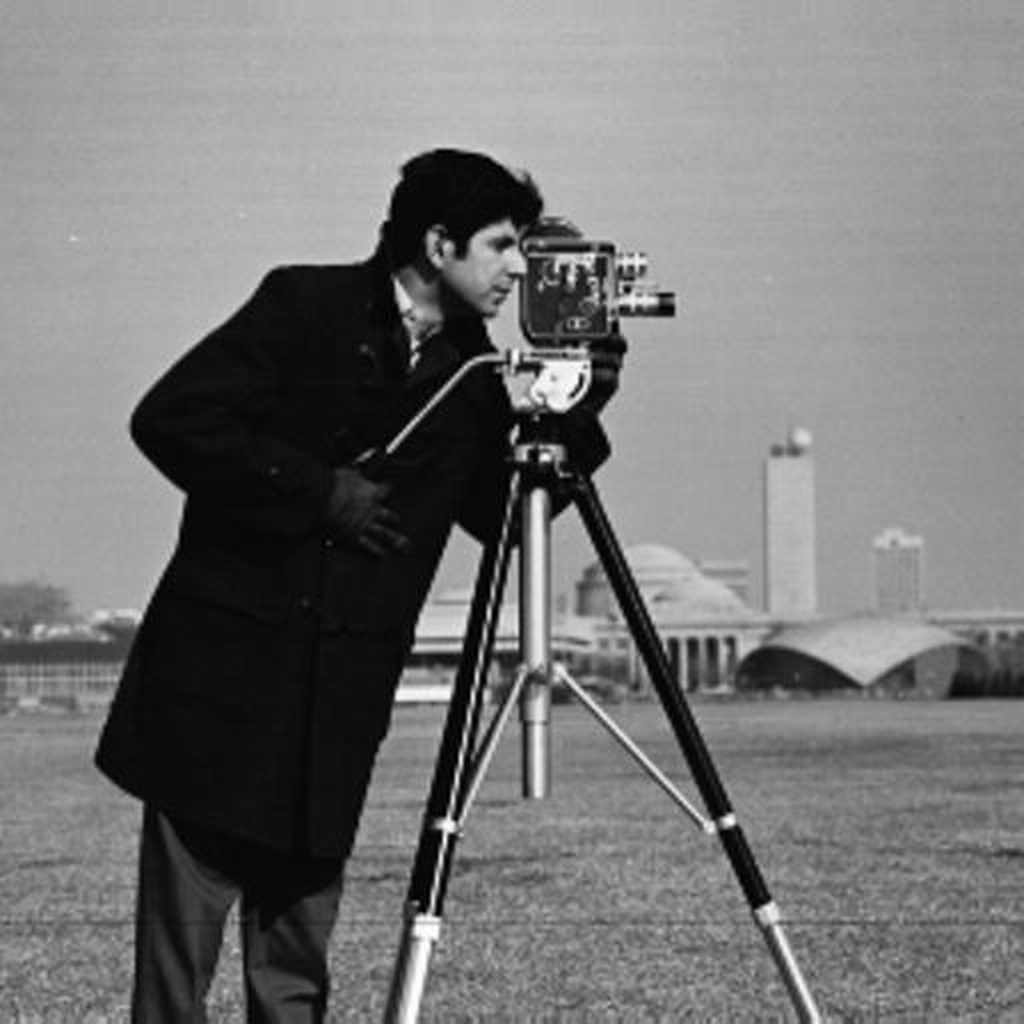

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_img = img.resize((int(width * cx), int(height * cy)), Image.Resampling.LANCZOS )
scaled_img

In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)


Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx = 2
cy = 1

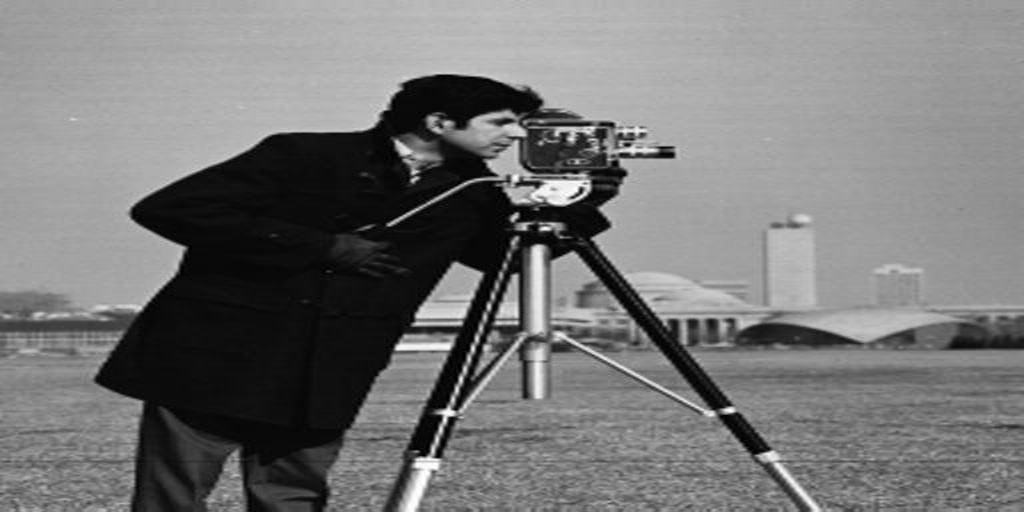

In [7]:
stretched_img = img.resize((int(width * cx), int(height * cy)),Image.Resampling.LANCZOS)
stretched_img

In [8]:
stretched_img.save("task1_1_non_uniform_scaled.jpg")

print("Original size:", img.size)
print("Stretched size:", stretched_img.size)

Original size: (512, 512)
Stretched size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


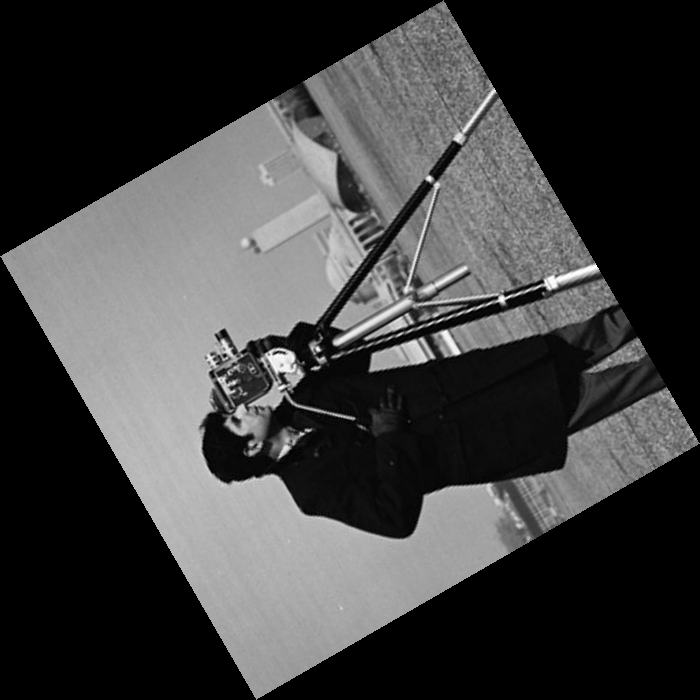

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate( 120,resample=Image.Resampling.BICUBIC, expand=True)
rotated_img.save("task1_2_rotated.jpg")
print("Original size:", img.size)
print("Rotated size:", rotated_img.size)
rotated_img


### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
shear_matrix = ( 1, -shear_factor, 0, 0, 1, 0)
new_width = int(width + abs(shear_factor) * height)
new_height = height


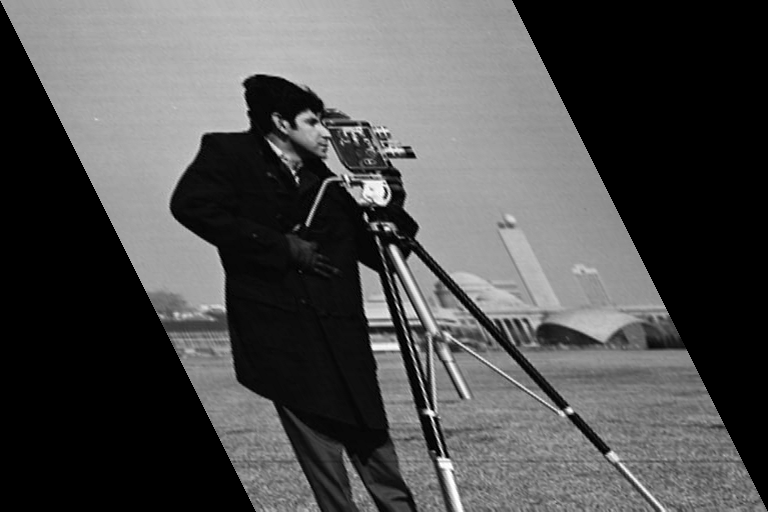

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform((new_width, new_height),Image.Transform.AFFINE, shear_matrix, resample=Image.Resampling.BICUBIC )
sheared_img

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

X-axis shear, factor = 0.1


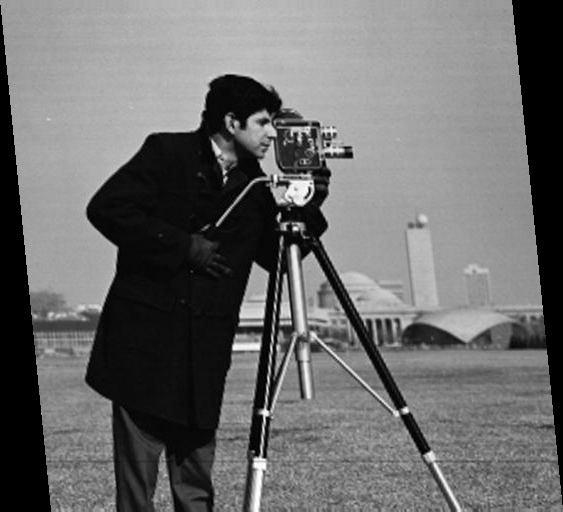

Y-axis shear, factor = 0.1


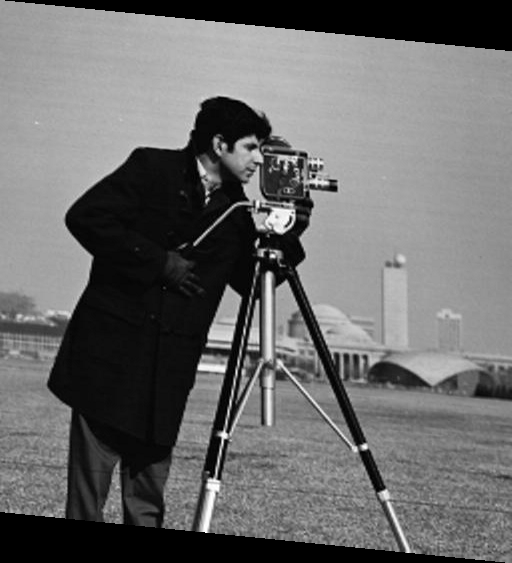

Combined X and Y shear, factor = 0.1


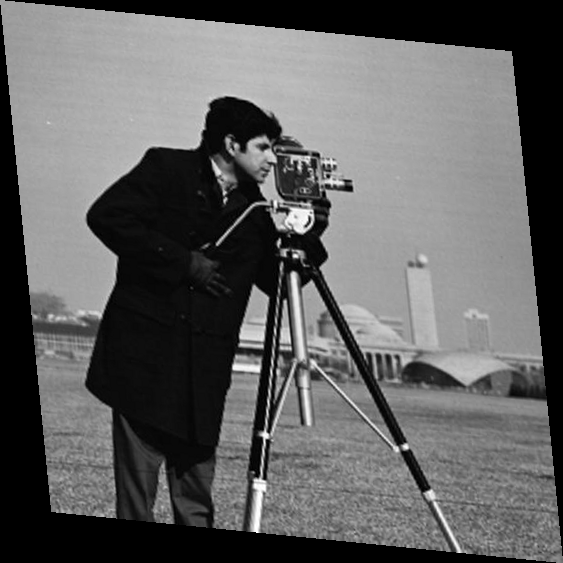

X-axis shear, factor = 0.3


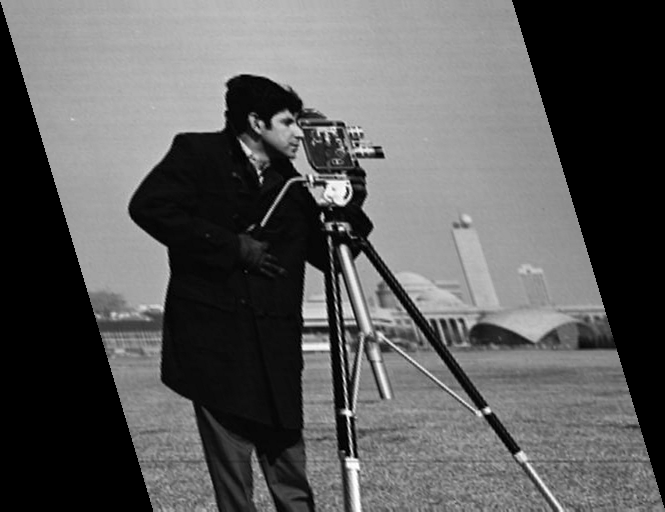

Y-axis shear, factor = 0.3


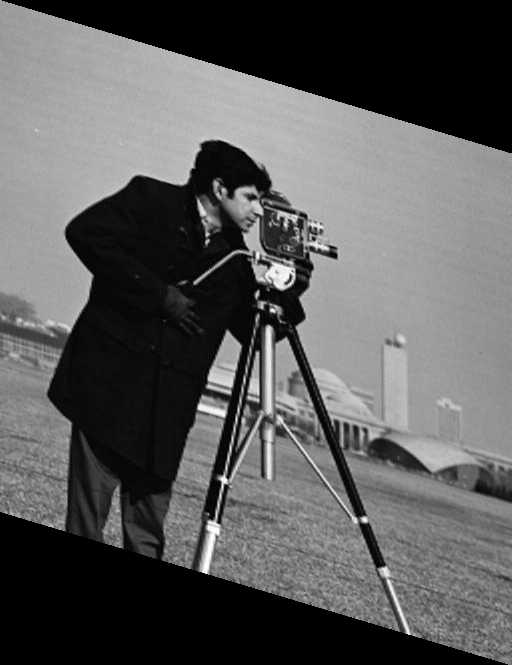

Combined X and Y shear, factor = 0.3


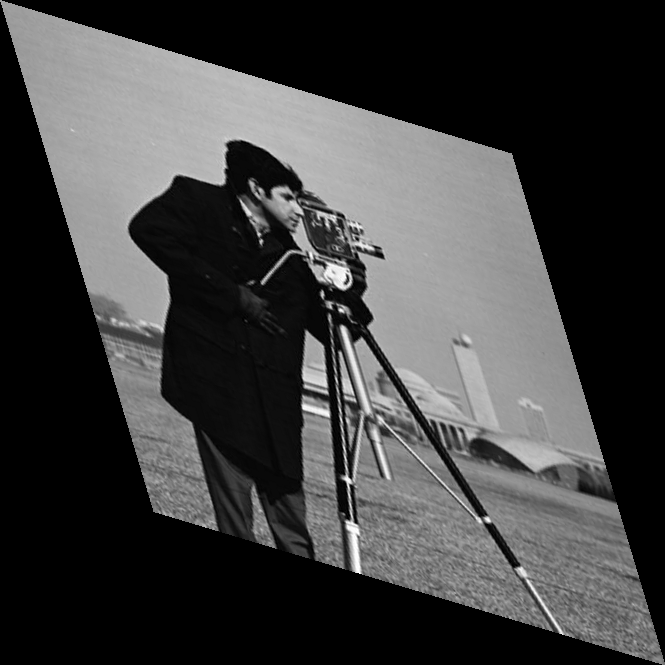

X-axis shear, factor = 0.8


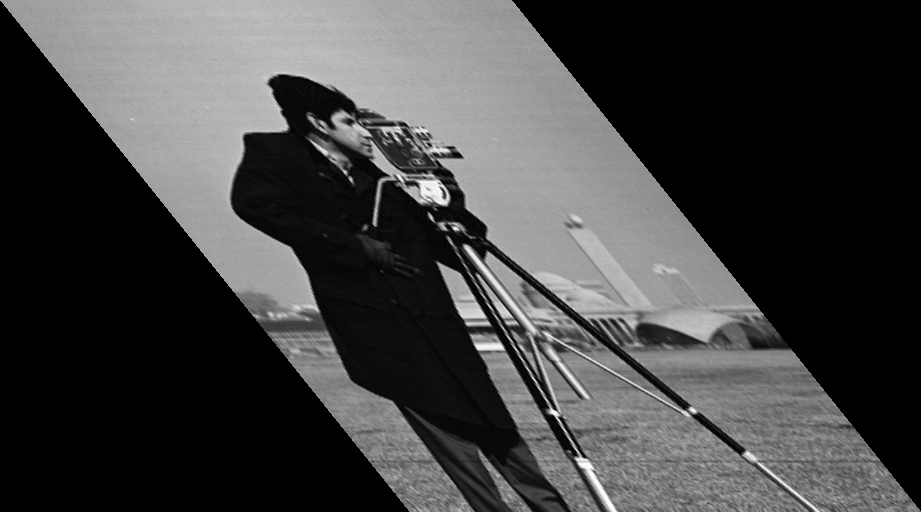

Y-axis shear, factor = 0.8


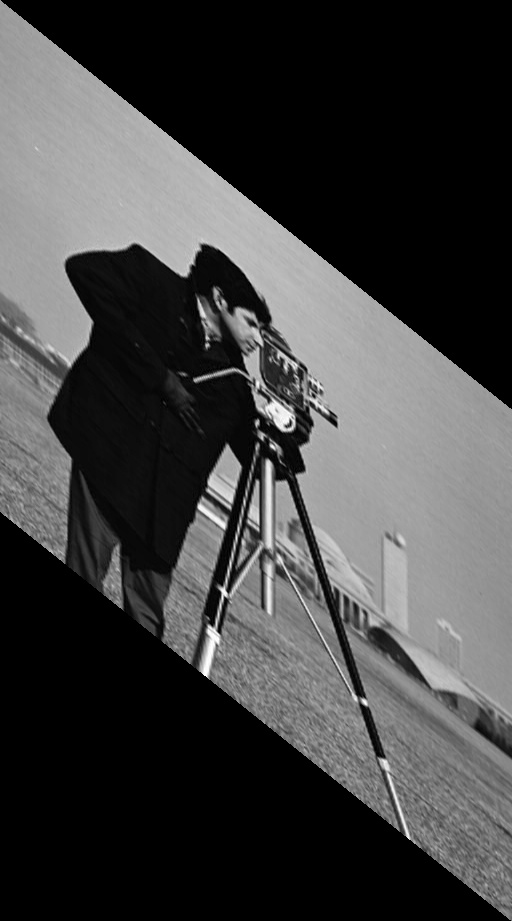

Combined X and Y shear, factor = 0.8


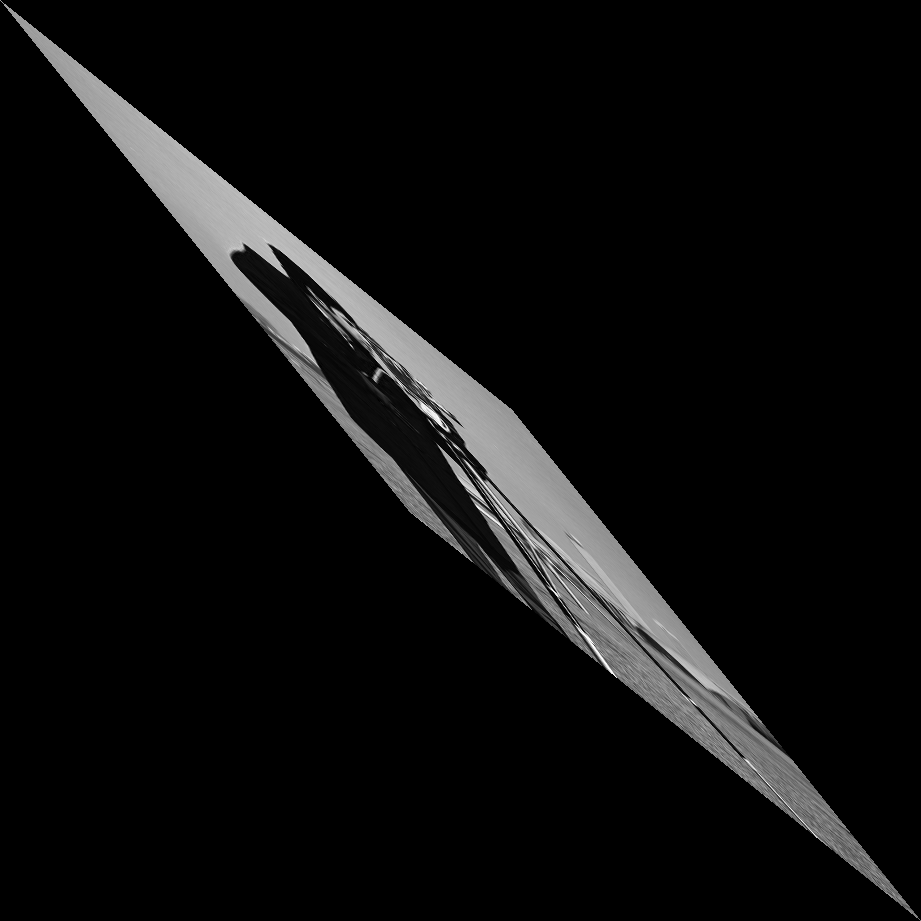

In [18]:
from IPython.display import display
shear_factors = [0.1, 0.3, 0.8]
for factor in shear_factors:
    x_width = int(width + abs(factor) * height)
    x_height = height
    x_matrix = (1, -factor, 0, 0, 1, 0)
    x_sheared = img.transform((x_width, x_height), Image.Transform.AFFINE, x_matrix, resample=Image.Resampling.BICUBIC )
    x_sheared.save(f"shear_x_{factor}.jpg")
    print(f"X-axis shear, factor = {factor}")
    display(x_sheared)
    y_width = width
    y_height = int(height + abs(factor) * width)
    y_matrix = (1, 0, 0, -factor, 1, 0)
    y_sheared = img.transform( (y_width, y_height),Image.Transform.AFFINE,y_matrix,resample=Image.Resampling.BICUBIC)
    y_sheared.save(f"shear_y_{factor}.jpg")
    print(f"Y-axis shear, factor = {factor}")
    display(y_sheared)
    combined_width = int(width + abs(factor) * height)
    combined_height = int(height + abs(factor) * width)
    determinant = 1 - factor**2
    combined_matrix = (  1 / determinant, -factor / determinant, 0, -factor / determinant,1 / determinant, 0)
    combined_sheared = img.transform( (combined_width, combined_height), Image.Transform.AFFINE, combined_matrix, resample=Image.Resampling.BICUBIC)
    combined_sheared.save(f"shear_xy_{factor}.jpg")
    print(f"Combined X and Y shear, factor = {factor}")
    display(combined_sheared)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

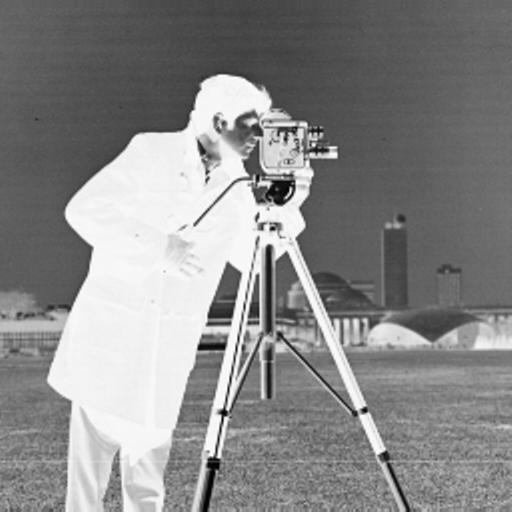

In [14]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
img_array = np.array(img)
negative_array = 255 - img_array
negative_img_numpy = Image.fromarray(negative_array)
negative_img_numpy.save("task2_1_negative_numpy.jpg")
negative_img_numpy

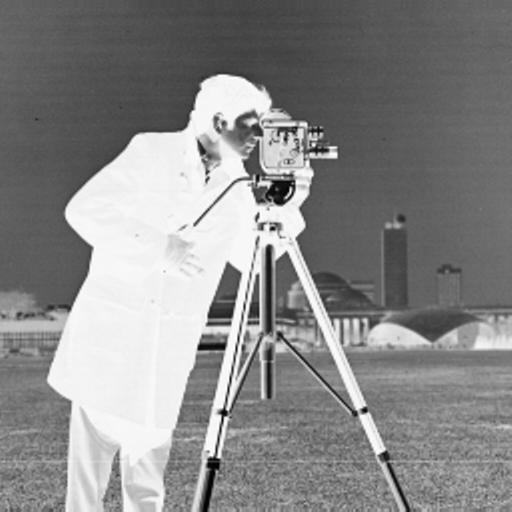

In [15]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img.convert("RGB"))
negative_img_pil.save("task2_1_negative_pil.jpg")
negative_img_pil

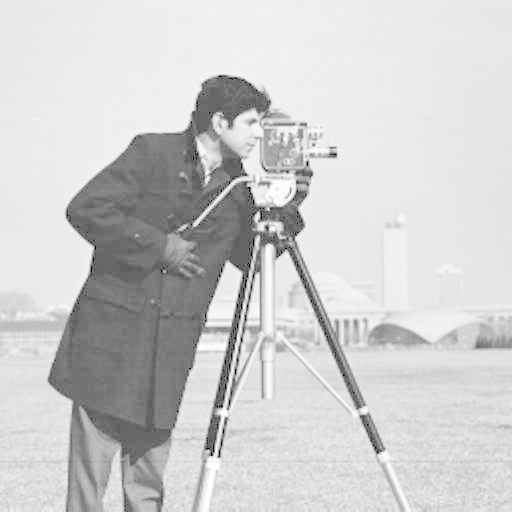

In [16]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
# Apply the log transformation to each pixel
img_array = np.array(img, dtype=np.float32)
c = 255 / np.log(1 + 255)
log_array = c * np.log(1 + img_array)
log_array = np.uint8(np.clip(log_array, 0, 255))
log_img = Image.fromarray(log_array)
log_img.save("task2_2_log.jpg")
log_img

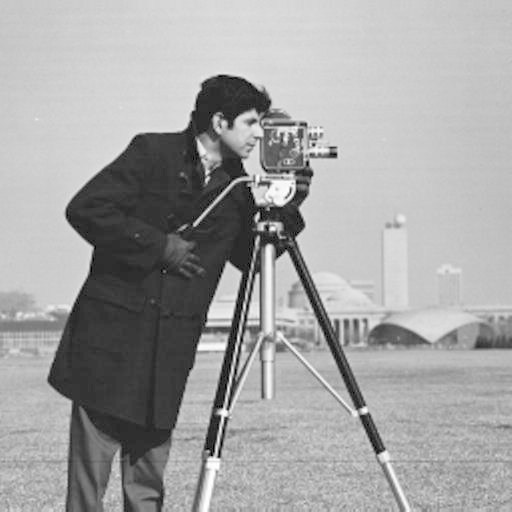

In [17]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
img_array = np.array(img, dtype=np.float32)
normalized_array = img_array / 255.0
gamma_array = 255 * (normalized_array ** gamma)
gamma_array = np.uint8(np.clip(gamma_array, 0, 255))
gamma_img = Image.fromarray(gamma_array)
gamma_img.save("task2_3_gamma.jpg")
gamma_img